In [43]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import re
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification


def set_seed(seed = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

set_seed(42)

plt.style.use('ggplot')

DATA_DIR = 'D:\\netpoint\\arabic-sentiment-ai-challenge'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sub_df = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Sub shape: {sub_df.shape}')


Train shape: (84443, 7)
Test shape: (21222, 6)
Sub shape: (21222, 2)


In [44]:
train_df.head()

,Review_ID,Hotel_Name,Sentiment,User_Type,Room_Type,Nights,Review
0,3,فندق 72,1,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
1,16,فندق 72,1,زوج,-,أقمت ليلتين,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...
2,20,فندق 72,0,زوج,غرفة قياسية مزدوجة,أقمت ليلة واحدة,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...
3,25,فندق 72,1,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,“جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...
4,26,فندق 72,1,مسافر منفرد,-,أقمت ليلتين,“فندق ممتاز”. الاثاث، النظافه.


In [45]:
print("Train Info")
train_df.info()

print("\n Missing Values in Train Data")
print(train_df.isnull().sum())

print("\n Missing Values in Test Data")
print(test_df.isnull().sum())


Train Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84443 entries, 0 to 84442
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Review_ID   84443 non-null  int64 
 1   Hotel_Name  84443 non-null  object
 2   Sentiment   84443 non-null  int64 
 3   User_Type   84443 non-null  object
 4   Room_Type   84443 non-null  object
 5   Nights      84443 non-null  object
 6   Review      84443 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.5+ MB

 Missing Values in Train Data
Review_ID     0
Hotel_Name    0
Sentiment     0
User_Type     0
Room_Type     0
Nights        0
Review        0
dtype: int64

 Missing Values in Test Data
Review_ID     0
Hotel_Name    0
User_Type     0
Room_Type     0
Nights        0
Review        0
dtype: int64


In [46]:
print("Sentiment Counts")
print(train_df['Sentiment'].value_counts())

print("\nSentiment Percentage")
print(train_df['Sentiment'].value_counts(normalize=True) * 100)

Sentiment Counts
Sentiment
0    42261
1    42182
Name: count, dtype: int64

Sentiment Percentage
Sentiment
0    50.046777
1    49.953223
Name: proportion, dtype: float64


In [47]:
train_df['word_count'] = train_df['Review'].astype(str).apply(lambda x: len(x.split()))
train_df["char_count"] = train_df['Review'].astype(str).apply(lambda x: len(x))

print (train_df[['word_count', 'char_count']].describe())


print("75th percentile:", np.percentile(train_df['word_count'], 75))
print("90th percentile:", np.percentile(train_df['word_count'], 90))
print("95th percentile:", np.percentile(train_df['word_count'], 95))
print("99th percentile:", np.percentile(train_df['word_count'], 99))


         word_count    char_count
count  84443.000000  84443.000000
mean      24.012932    137.415369
std       24.694019    137.781849
min        2.000000      6.000000
25%        9.000000     54.000000
50%       17.000000     97.000000
75%       30.000000    172.000000
max      614.000000   3365.000000
75th percentile: 30.0
90th percentile: 50.0
95th percentile: 67.0
99th percentile: 119.0


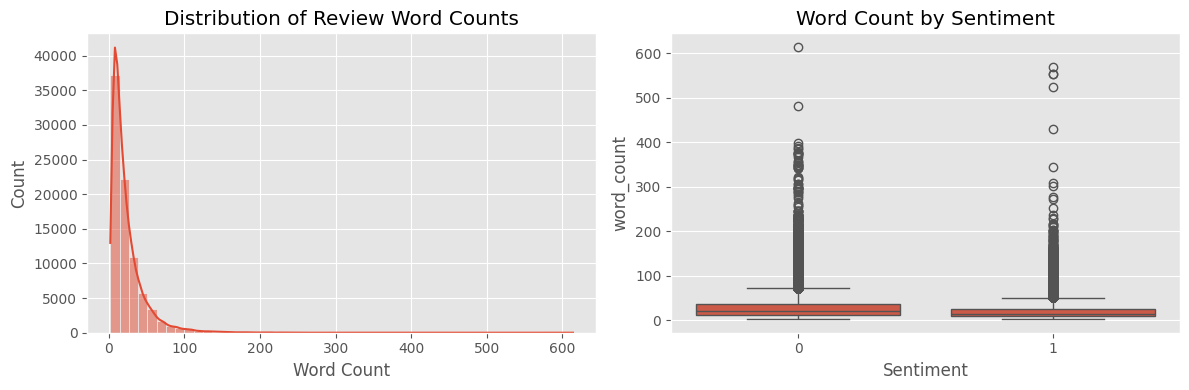

In [48]:
# Visualizing review length
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Review Word Counts')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Sentiment', y='word_count')
plt.title('Word Count by Sentiment')
plt.xlabel('Sentiment')

plt.tight_layout()
plt.show()

In [49]:
print ("Sample Neg Review(0)")
neg_sample =  train_df[train_df['Sentiment'] == 0]['Review'].dropna().iloc[0]
print(neg_sample)

print ("Sample Positive Review(1)")
pos_sample =  train_df[train_df['Sentiment'] == 1]['Review'].dropna().iloc[0]
print(pos_sample)

Sample Neg Review(0)
“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق 2 نجمه 
Sample Positive Review(1)
استثنائي. سهولة إنهاء المعاملة في الاستقبال. لاشيئ


In [50]:
def clean_arabic_text(text):
    text  = str(text)
    # removing tashkel from arabic text   
    tashkel_regex = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = re.sub(tashkel_regex, '', text)

    # removing tatweel from arabic text
    text = re.sub(r'ـ', '', text)

    # Normalize Alef forms
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Taa Marbuta (ة) to Haa (ه)
    text = re.sub(r'ة', 'ه', text)

    # Normalize Ya (ي) to Alif Maqsura (ى)
    text = re.sub(r'ى', 'ي', text)

    # Normalize repeated Chars
    text  =  re.sub(r'(.)\1{2,}', r'\1\1', text)

    #remove non-Arabic characters
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    # Collapse extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'([^\s\u0621-\u064A])', r' \1 ', text)
    
    return text


In [51]:
print("Cleaning Train reviews")
train_df['cleaned_review'] = train_df['Review'].apply(clean_arabic_text)

print("Cleaning Test reviews")
test_df['cleaned_review'] = test_df['Review'].apply(clean_arabic_text)

train_df[['Review', 'cleaned_review']].head(3)

Cleaning Train reviews
Cleaning Test reviews


,Review,cleaned_review
0,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,استثنائي سهوله انهاء المعامله في الاستقبال لاشيئ
1,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,استثنائي انصح باختيار الاسويت و بالاخص غرفه رق...
2,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,استغرب تقييم الفندق كخمس نجوم لا شي يستحق نجمه


In [52]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df['cleaned_review'].values,
    train_df['Sentiment'].values,
    test_size=0.2,
    random_state=42,
    stratify=train_df['Sentiment'].values
)
print(f"Training set size: {len(X_train_text)}")
print(f"Validation set size: {len(X_val_text)}")

Training set size: 67554
Validation set size: 16889


In [53]:
# hyperparameters

MAX_VOCAB_SIZE = 25000
MAX_LEN = 100
EMBEDDING_DIM = 128
BATCH_SZIE = 64

vectorize_layer  =  TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
# fit only on training data
vectorize_layer.adapt(X_train_text)

print(f"Vocabulary size adapted: {len(vectorize_layer.get_vocabulary())} words")

Vocabulary size adapted: 25000 words


In [54]:
sample_text  = "فندق رائع و خدمة ممتارة"
vectorized_sample = vectorize_layer([sample_text])
print("vectorized shape", vectorized_sample.shape)
print("vectorized output", vectorized_sample.numpy())

vectorized shape (1, 100)
vectorized output [[19 29  8  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0]]


In [55]:
def get_callback(model_name):
    callbacks = [
        EarlyStopping(
            monitor = 'val_accuracy',
            patience = 2,
            restore_best_weights = True,
            verbose = 1
        )
    ]
    return callbacks

In [56]:
model_rnn = models.Sequential([
    layers.Input(shape =(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim = EMBEDDING_DIM),
    layers.SimpleRNN(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation= 'sigmoid')
] , name = 'Vanilla_RNN')

model_rnn.compile(
    optimizer  = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model_rnn.summary()

Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization_3                 │ (None, 100)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_5 (Embedding)              │ (None, 100, 128)            │       3,200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,212,417 (12.25 MB)

 Trainable params: 3,212,417 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
EPOCHS = 5

history_rnn = model_rnn.fit(
    X_train_text , y_train,
    validation_data = (X_val_text, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SZIE,
    callbacks = get_callback('Vanilla_RNN')
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.5058 - loss: 0.6915 - val_accuracy: 0.5078 - val_loss: 0.6912
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.5084 - loss: 0.6890 - val_accuracy: 0.4932 - val_loss: 0.6958
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.5084 - loss: 0.6909 - val_accuracy: 0.5066 - val_loss: 0.6941
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [58]:
# Bidirectional LSTM

model_lstm = models.Sequential([
    layers.Input(shape =(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim = EMBEDDING_DIM, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64,dropout=0.2, return_sequences=False)),
    layers.Dense(32,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation= 'sigmoid')
], name = "Bidirectional_LSTM")

model_lstm.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)
model_lstm.summary()

Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization_3                 │ (None, 100)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 100, 128)            │       3,200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,302,977 (12.60 MB)

 Trainable params: 3,302,977 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
EPOCHS = 5

history_lstm = model_lstm.fit(
    X_train_text , y_train,
    validation_data = (X_val_text, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SZIE,
    callbacks = get_callback('Bidirectional_LSTM')
) 

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 78s 70ms/step - accuracy: 0.9379 - loss: 0.1788 - val_accuracy: 0.9494 - val_loss: 0.1414
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 75s 71ms/step - accuracy: 0.9644 - loss: 0.1077 - val_accuracy: 0.9453 - val_loss: 0.1529
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 74s 70ms/step - accuracy: 0.9758 - loss: 0.0749 - val_accuracy: 0.9417 - val_loss: 0.1912
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [60]:
# Model 3: Bidirectional GRU
model_gru = models.Sequential([
    layers.Input(shape = (1,),dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim = MAX_VOCAB_SIZE, output_dim = EMBEDDING_DIM, mask_zero=True),
    layers.Bidirectional(layers.GRU(64, dropout=0.2, return_sequences=False)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name = "Bidirectional_GRU")

model_gru.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model_gru.summary()

Model: "Bidirectional_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization_3                 │ (None, 100)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_7 (Embedding)              │ (None, 100, 128)            │       3,200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 128)                 │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,278,657 (12.51 MB)

 Trainable params: 3,278,657 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
EPOCHS = 5

model_gru_history = model_gru.fit(
    X_train_text, y_train,
    validation_data = (X_val_text, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SZIE,
    callbacks = get_callback('Bidirectional_GRU')
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.9371 - loss: 0.1783 - val_accuracy: 0.9474 - val_loss: 0.1427
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 80s 76ms/step - accuracy: 0.9647 - loss: 0.1073 - val_accuracy: 0.9471 - val_loss: 0.1547
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.9770 - loss: 0.0728 - val_accuracy: 0.9390 - val_loss: 0.1914
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [62]:
# Bidrectional LSTM with Attention Mechanism

inputs = layers.Input(shape=(1,), dtype=tf.string, name='text_input')
x = vectorize_layer(inputs)
x = layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM)(x)

lstm_seq = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(x)

attention_out = layers.MultiHeadAttention(num_heads=2, key_dim=64)(lstm_seq, lstm_seq)
x = layers.LayerNormalization()(lstm_seq + attention_out)
pooled = layers.GlobalAveragePooling1D()(attention_out)


dense_1 = layers.Dense(32, activation='relu')(pooled)
dropout_1 = layers.Dropout(0.3)(dense_1)

outputs = layers.Dense(1, activation='sigmoid')(dropout_1)

model_attention = models.Model(inputs=inputs, outputs=outputs, name='Bidirectional_LSTM_with_Attention')

model_attention.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_attention.summary()

Model: "Bidirectional_LSTM_with_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ text_vectorization_3          │ (None, 100)               │               0 │ text_input[0][0]           │
│ (TextVectorization)           │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_8 (Embedding)       │ (None, 100, 128)          │       3,200,000 │ text_vectorization_3[3][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_5               │ (None, 100, 128)          │          98,816 │ embedding_8[0][0]          │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_2        │ (None, 100, 128)          │          66,048 │ bidirectional_5[0][0],     │
│ (MultiHeadAttention)          │                           │                 │ bidirectional_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_2    │ (None, 128)               │               0 │ multi_head_attention_2[0]… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 32)                │           4,128 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_13 (Dropout)          │ (None, 32)                │               0 │ dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 1)                 │              33 │ dropout_13[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,369,025 (12.85 MB)

 Trainable params: 3,369,025 (12.85 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
EPOCHS = 5
history_attention = model_attention.fit(
    X_train_text, y_train,
    validation_data=(X_val_text, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SZIE,
    callbacks=get_callback('Bidirectional_LSTM_with_Attention')
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - accuracy: 0.9193 - loss: 0.2065 - val_accuracy: 0.9449 - val_loss: 0.1529
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 90s 85ms/step - accuracy: 0.9589 - loss: 0.1233 - val_accuracy: 0.9432 - val_loss: 0.1608
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 89s 84ms/step - accuracy: 0.9702 - loss: 0.0922 - val_accuracy: 0.9375 - val_loss: 0.1740
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [64]:
model_dict = {
    "Vanilla_RNN": model_rnn,
    "Bidirectional_LSTM": model_lstm,
    "Bidirectional_GRU": model_gru,
    "Bidirectional_LSTM_with_Attention": model_attention

}
results = []

for name, model in model_dict.items():
    loss, acc = model.evaluate(X_val_text, y_val, verbose=0)
    trainable_params = sum ([tf.size(w).numpy() for w in model.trainable_weights])
    results.append({
        "Model": name,
        "validation Accuracy": f"{acc *100:.2f}%",
        "validation Loss": f"{loss:.4f}",
        "trainable parameters": trainable_params
    })
comparison_df = pd.DataFrame(results)
print("Progressive Architectural Benchmark")
display(comparison_df)

Progressive Architectural Benchmark


,Model,validation Accuracy,validation Loss,trainable parameters
0,Vanilla_RNN,50.78%,0.6912,3212417
1,Bidirectional_LSTM,94.94%,0.1414,3302977
2,Bidirectional_GRU,94.74%,0.1427,3278657
3,Bidirectional_LSTM_with_Attention,94.49%,0.1529,3369025


In [65]:
# Predict Prob
best_model = model_gru
val_preds_prob = best_model.predict(X_val_text, batch_size=BATCH_SZIE).flatten()
val_preds  = (val_preds_prob > 0.5).astype(int)

errors_df = pd.DataFrame({
    'Review': X_val_text,
    'True_Sentiment': y_val,
    'Predicted_Sentiment': val_preds,
    'Confidence': val_preds_prob
})

misclassified = errors_df[errors_df['True_Sentiment'] != errors_df['Predicted_Sentiment']]
print(f"Total Misclassified Reviews: {len(misclassified)} out of {len(y_val)}")


264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
Total Misclassified Reviews: 888 out of 16889


In [66]:
print("False Positive")
for idx , row in misclassified[misclassified['True_Sentiment'] == 0].head(3).iterrows():
    print(f"Confidence: {row['Confidence']:.2f} | Review: {row['Review']}")

False Positive
Confidence: 0.98 | Review: راحه تامه نعم كل شيء تمام
Confidence: 0.75 | Review: معتمر القرب من الحرم السعر مبالغ فيه جدا مقارنه بالخدمات والمستوي
Confidence: 0.59 | Review: راي في الفندق الغرف مناسبه والمرافق لها كويسه خدمات الغرف لم يتيم تغير المفارش والمناشفوعدم الاستجابه السريعه لطالبات


In [67]:
print("False Negative")
for idx , row in misclassified[misclassified['True_Sentiment'] == 1].head(3).iterrows():
    print(f"Confidence: {row['Confidence']:.2f} | Review: {row['Review']}")

False Negative
Confidence: 0.49 | Review: الفندق قريب من الحرم الموظفين محترمين جدا المستوي اقل من خمس نجوم الموقع ممتاز و العاملين علي درجه كبيره من الاحترام و النفس الطيبهتم تغير الغرفه الي اكبر من الاولي وتم ذلك دون اي مبلغ اضافي لا يستحق ان يكون خمس نجوم بعض الغرف يكون فيها فواكه و حلويات و الاخري لا مع انه تم الحجز بنفس المستوي و السعر المصاعد صغيره لا ترقي الي خمس نجوم المتعلقات الشخصيه في الحمام و المحارم الورقيه ناقصه علما بانه يتم توصيلها عند الطلب
Confidence: 0.10 | Review: اقامه مقبوله الموقع ممتازالتجهيزات لا باس بها سوء نظافه فرش الارضياتتجهيزات المطبخ غير مكتملهعدم وجود محارم في الحماماتسوء الصيانه رغم ان المبني جديدعدم وجود خط هاتف للاتصال المحلي يوجد خط اتصال داخل المبني فقطالواي فاي ضعيف
Confidence: 0.35 | Review: قيمه جيده جهود رائعه تعكس رغبه العاملين بالتحسين المستمر حسب امكانياتهم المتاحه مواقف السيارات غير مريحه لا من ناحيه عددها او طريقه توزيعها واستخدامها


In [68]:
# Keras Transformer Encoder
inputs = layers.Input(shape=(1,), dtype=tf.string, name="text_input")


x = vectorize_layer(inputs)
embed = layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM)(x)


attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=EMBEDDING_DIM)(embed, embed)
attention_out = layers.Dropout(0.1)(attention_out)
x1 = layers.LayerNormalization(epsilon=1e-6)(embed + attention_out)


ffn = layers.Dense(256, activation="relu")(x1)
ffn = layers.Dense(EMBEDDING_DIM)(ffn)
ffn = layers.Dropout(0.1)(ffn)
x2 = layers.LayerNormalization(epsilon=1e-6)(x1 + ffn)


pooled = layers.GlobalAveragePooling1D()(x2)
dense = layers.Dense(32, activation="relu")(pooled)
dense = layers.Dropout(0.3)(dense)
outputs = layers.Dense(1, activation="sigmoid")(dense)

model_transformer = models.Model(inputs=inputs, outputs=outputs, name="Transformer_Encoder")

model_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_transformer.summary()

Model: "Transformer_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ text_vectorization_3          │ (None, 100)               │               0 │ text_input[0][0]           │
│ (TextVectorization)           │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_9 (Embedding)       │ (None, 100, 128)          │       3,200,000 │ text_vectorization_3[4][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_3        │ (None, 100, 128)          │         263,808 │ embedding_9[0][0],         │
│ (MultiHeadAttention)          │                           │                 │ embedding_9[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_15 (Dropout)          │ (None, 100, 128)          │               0 │ multi_head_attention_3[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_4 (Add)                   │ (None, 100, 128)          │               0 │ embedding_9[0][0],         │
│                               │                           │                 │ dropout_15[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_4         │ (None, 100, 128)          │             256 │ add_4[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_18 (Dense)              │ (None, 100, 256)          │          33,024 │ layer_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 100, 128)          │          32,896 │ dense_18[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_16 (Dropout)          │ (None, 100, 128)          │               0 │ dense_19[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_5 (Add)                   │ (None, 100, 128)          │               0 │ layer_normalization_4[0][… │
│                               │                           │                 │ dropout_16[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_5         │ (None, 100, 128)          │             256 │ add_5[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_3    │ (None, 128)               │               0 │ layer_normalization_5[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_20 (Dense)              │ (None, 32)                │           4,12

 Total params: 3,534,401 (13.48 MB)

 Trainable params: 3,534,401 (13.48 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
EPOCHS = 5
history_transformer = model_transformer.fit(
    X_train_text, y_train,
    validation_data = (X_val_text, y_val),
    epochs = EPOCHS,
    batch_size = BATCH_SZIE,
    callbacks=get_callback("transformer")
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 131s 122ms/step - accuracy: 0.8817 - loss: 0.2745 - val_accuracy: 0.9333 - val_loss: 0.1801
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 128s 121ms/step - accuracy: 0.9455 - loss: 0.1607 - val_accuracy: 0.9314 - val_loss: 0.2085
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 127s 120ms/step - accuracy: 0.9580 - loss: 0.1232 - val_accuracy: 0.9252 - val_loss: 0.2577
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [70]:
models_dict = {
    "Vanilla RNN": model_rnn,
    "Bidirectional LSTM": model_lstm,
    "Bidirectional GRU": model_gru,
    "BiLSTM + Attention": model_attention,
    "Transformer Encoder": model_transformer
}

results = []
for name, model in models_dict.items():
    loss, acc = model.evaluate(X_val_text, y_val, verbose=0)
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    results.append({
        "Model": name,
        "Validation Accuracy": f"{acc * 100:.2f}%",
        "Validation Loss": f"{loss:.4f}",
        "Trainable Parameters": f"{trainable_params:,}"
    })

benchmark_df = pd.DataFrame(results)
print("=== Final Architectural Comparison Table ===")
display(benchmark_df)

=== Final Architectural Comparison Table ===


,Model,Validation Accuracy,Validation Loss,Trainable Parameters
0,Vanilla RNN,50.78%,0.6912,"3,212,417"
1,Bidirectional LSTM,94.94%,0.1414,"3,302,977"
2,Bidirectional GRU,94.74%,0.1427,"3,278,657"
3,BiLSTM + Attention,94.49%,0.1529,"3,369,025"
4,Transformer Encoder,93.33%,0.1801,"3,534,401"


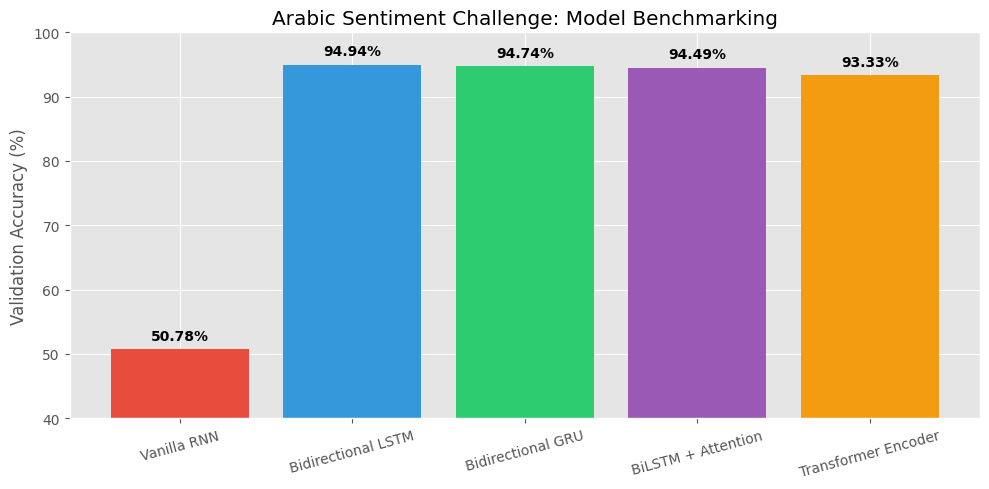

In [71]:
plt.figure(figsize=(10, 5))
names = [r['Model'] for r in results]
accs = [float(r['Validation Accuracy'].replace('%', '')) for r in results]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

bars = plt.bar(names, accs, color=colors)
plt.ylabel('Validation Accuracy (%)')
plt.title('Arabic Sentiment Challenge: Model Benchmarking')
plt.ylim(40, 100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y + 1, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [74]:

best_model = model_gru

print("Generating predictions for test set...")

test_probs = best_model.predict(test_df['cleaned_review'].values, batch_size=64).flatten()


test_preds = (test_probs >= 0.5).astype(int)


submission = pd.DataFrame({
    'Review_ID': test_df['Review_ID'],
    'Sentiment': test_preds
})


print("\n--- Submission Checks ---")
print(f"Total rows: {len(submission)} (Expected: {len(test_df)})")
print(f"Columns: {list(submission.columns)}")
print("\nFirst 5 rows:")
print(submission.head())

print("\nClass distribution in predictions:")
print(submission['Sentiment'].value_counts(normalize=True))


submission_filename = 'submission_best_gru.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nSaved successfully to '{submission_filename}'!")

Generating predictions for test set...
332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

--- Submission Checks ---
Total rows: 21222 (Expected: 21222)
Columns: ['Review_ID', 'Sentiment']

First 5 rows:
   Review_ID  Sentiment
0     241096          1
1     397912          0
2     323390          0
3     365977          1
4     321051          1

Class distribution in predictions:
Sentiment
1    0.513806
0    0.486194
Name: proportion, dtype: float64

Saved successfully to 'submission_best_gru.csv'!


In [ ]:

probs_gru = model_gru.predict(test_df['cleaned_review'].values, batch_size=64).flatten()
probs_lstm = model_lstm.predict(test_df['cleaned_review'].values, batch_size=64).flatten()
probs_att = model_attention.predict(test_df['cleaned_review'].values, batch_size=64).flatten()


blended_probs = (0.45 * probs_gru) + (0.30 * probs_lstm) + (0.25 * probs_att)


ensemble_preds = (blended_probs >= 0.5).astype(int)


sub_ensemble = pd.DataFrame({
    'Review_ID': test_df['Review_ID'],
    'Sentiment': ensemble_preds
})
sub_ensemble.to_csv('submission_ensemble_weighted.csv', index=False)
print("Weighted ensemble saved!")

332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
Weighted ensemble saved!


In [ ]:

def build_rich_text(df):
    meta = "فندق " + df['Hotel_Name'].astype(str) + " . " + \
           "نزيل " + df['User_Type'].astype(str) + " . " + \
           "غرفة " + df['Room_Type'].astype(str) + " . " + \
           "اقامة " + df['Nights'].astype(str) + " . "
    return meta + df['cleaned_review']

train_df['rich_text'] = build_rich_text(train_df)
test_df['rich_text'] = build_rich_text(test_df)

print("Enriched sample:")
print(train_df['rich_text'].iloc[0])

Enriched sample:
فندق فندق 72 . نزيل زوج . غرفة غرفة ديلوكس مزدوجة أو توأم . اقامة أقمت ليلة واحدة . استثنائي سهوله انهاء المعامله في الاستقبال لاشيئ


In [ ]:

X_train_rich, X_val_rich, y_train_rich, y_val_rich = train_test_split(
    train_df['rich_text'].values,
    train_df['Sentiment'].values,
    test_size=0.20,
    random_state=42,
    stratify=train_df['Sentiment'].values
)


vectorize_rich = layers.TextVectorization(
    max_tokens=30000,  
    output_mode='int',
    output_sequence_length=120  
)
vectorize_rich.adapt(X_train_rich)


inputs = layers.Input(shape=(1,), dtype=tf.string)
x = vectorize_rich(inputs)
x = layers.Embedding(input_dim=30000, output_dim=128, mask_zero=True)(x)
x = layers.Bidirectional(layers.GRU(64, dropout=0.2))(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_gru_rich = models.Model(inputs=inputs, outputs=outputs, name="BiGRU_RichText")
model_gru_rich.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


history_rich = model_gru_rich.fit(
    X_train_rich, y_train_rich,
    validation_data=(X_val_rich, y_val_rich),
    epochs=5,
    batch_size=64,
    callbacks=get_callback("gru_rich")
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 93s 84ms/step - accuracy: 0.9189 - loss: 0.2098 - val_accuracy: 0.9498 - val_loss: 0.1405
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 97s 91ms/step - accuracy: 0.9642 - loss: 0.1137 - val_accuracy: 0.9464 - val_loss: 0.1497
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 99s 94ms/step - accuracy: 0.9760 - loss: 0.0807 - val_accuracy: 0.9430 - val_loss: 0.1733
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
p_gru = model_gru.predict(test_df['cleaned_review'].values, batch_size=64).flatten()
p_lstm = model_lstm.predict(test_df['cleaned_review'].values, batch_size=64).flatten()
p_att = model_attention.predict(test_df['cleaned_review'].values, batch_size=64).flatten()
p_rich = model_gru_rich.predict(test_df['rich_text'].values, batch_size=64).flatten()

final_blend = 0.25 * p_gru + 0.25 * p_lstm + 0.25 * p_att + 0.25 * p_rich
final_preds = (final_blend >= 0.50).astype(int)

sub_super_ensemble = pd.DataFrame({
    'Review_ID': test_df['Review_ID'],
    'Sentiment': final_preds
})
sub_super_ensemble.to_csv('submission_super_ensemble.csv', index=False)
print("Super Ensemble saved to submission_super_ensemble.csv!")

332/332 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
332/332 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Super Ensemble saved to submission_super_ensemble.csv!
